In [2]:
import os
import glob
import json
import pandas as pd

# ĐƯỜNG DẪN ĐÃ SỬA: Từ './data/' thành '../data/' vì notebook ở trong folder namtt/
folder_path = '../data/**/*.json' 

data_list = []

print("Đang đọc dữ liệu, vui lòng đợi...")

for file_path in glob.glob(folder_path, recursive=True):
    with open(file_path, 'r', encoding='utf-8') as f:
        try:
            data = json.load(f)
            
            properties = data.get('properties', {})
            geometry = data.get('geometry', {})
            coords = geometry.get('coordinates', [None, None, None])
            
            # Trích xuất các features cơ bản
            mag = properties.get('mag')
            place = properties.get('place')
            time_ms = properties.get('time')
            
            time = pd.to_datetime(time_ms, unit='ms') if time_ms else None
            
            lon = coords[0] if len(coords) > 0 else None
            lat = coords[1] if len(coords) > 1 else None
            depth = coords[2] if len(coords) > 2 else None
            
            event_type = properties.get('type')
            
            # Thêm các features bổ sung
            mag_type = properties.get('magType')
            status = properties.get('status')
            tsunami = properties.get('tsunami')
            sig = properties.get('sig')
            rms = properties.get('rms')
            net = properties.get('net')
            event_id = data.get('id')
            gap = properties.get('gap')
            dmin = properties.get('dmin')
            nst = properties.get('nst')
            
            data_list.append({
                'Time': time,
                'Magnitude': mag,
                'Place': place,
                'Longitude': lon,
                'Latitude': lat,
                'Depth': depth,
                'Type': event_type,
                'MagType': mag_type,
                'Status': status,
                'Tsunami': tsunami,
                'Significance': sig,
                'RMS': rms,
                'Network': net,
                'EventID': event_id,
                'Gap': gap,
                'Dmin': dmin,
                'Nst': nst
            })
        except Exception as e:
            print(f"Bỏ qua file {file_path} vì lỗi: {e}")

df = pd.DataFrame(data_list)

print("Đã đọc xong dữ liệu!")
print(f"Tổng số sự kiện thu thập được: {len(df)}")
print(f"\nCác cột trong DataFrame:")
print(df.columns.tolist())
print(f"\nThông tin tổng quan:")
print(df.info())

df.head()

Đang đọc dữ liệu, vui lòng đợi...
Đã đọc xong dữ liệu!
Tổng số sự kiện thu thập được: 1598809

Các cột trong DataFrame:
['Time', 'Magnitude', 'Place', 'Longitude', 'Latitude', 'Depth', 'Type', 'MagType', 'Status', 'Tsunami', 'Significance', 'RMS', 'Network', 'EventID', 'Gap', 'Dmin', 'Nst']

Thông tin tổng quan:
<class 'pandas.DataFrame'>
RangeIndex: 1598809 entries, 0 to 1598808
Data columns (total 17 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   Time          1598802 non-null  datetime64[ms]
 1   Magnitude     1598809 non-null  float64       
 2   Place         1598809 non-null  str           
 3   Longitude     1598809 non-null  float64       
 4   Latitude      1598809 non-null  float64       
 5   Depth         1597888 non-null  float64       
 6   Type          1598809 non-null  str           
 7   MagType       1598715 non-null  str           
 8   Status        1598808 non-null  str           
 9   Tsunami

,Time,Magnitude,Place,Longitude,Latitude,Depth,Type,MagType,Status,Tsunami,Significance,RMS,Network,EventID,Gap,Dmin,Nst
0,2013-06-29 16:50:52.000,4.4,"145 km WNW of Corral, Chile",-75.052,-39.497,43.2,earthquake,mb,reviewed,0,298,NaN,us,usb000i3dv,100.0,NaN,32.0
1,2013-07-22 05:58:55.600,4.4,"236 km WSW of Tual, Indonesia",130.672,-6.118,35.4,earthquake,mb,reviewed,0,298,1.03,us,usp000k293,87.0,NaN,24.0
2,2013-02-05 16:15:30.970,5.0,"97 km WNW of Naze, Japan",128.607,28.782,50.1,earthquake,mb,reviewed,0,385,0.92,us,usc000f1e6,72.7,NaN,147.0
3,2013-01-25 00:41:22.700,4.0,"6 km ESE of Cucuyulapa Primera Sección, Mexico",-93.200,17.967,20.0,earthquake,md,reviewed,0,246,NaN,us,us2013kvcq,208.3,NaN,6.0
4,2013-12-03 08:16:06.000,4.0,"124 km SW of Puerto Madero, Mexico",-93.220,13.910,20.0,earthquake,md,reviewed,0,246,0.52,us,usc000lx47,NaN,NaN,NaN


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.dropna(subset=['Magnitude', 'Longitude', 'Latitude', 'Depth'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)

scatter = sns.scatterplot(
    data=df, 
    x='Longitude', 
    y='Latitude', 
    hue='Depth',
    size='Magnitude',
    sizes=(10, 200),
    palette='viridis',
    alpha=0.7
)
plt.title('Bản đồ phân bố các trận động đất')
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Đẩy chú thích ra ngoài cho gọn



# --- BIỂU ĐỒ 2: Phân phối Độ lớn Động đất (Histogram) ---
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Magnitude', bins=30, kde=True, color='coral')
plt.title('Phân phối tần suất Độ lớn (Magnitude)')
plt.xlabel('Độ Richter (Magnitude)')
plt.ylabel('Số lượng trận động đất')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

/var/folders/lf/0v1t5pp154sdnytlyv057_d00000gn/T/ipykernel_91512/3827412658.py:8: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  earthquakes_per_year = df_time.resample('Y').size()


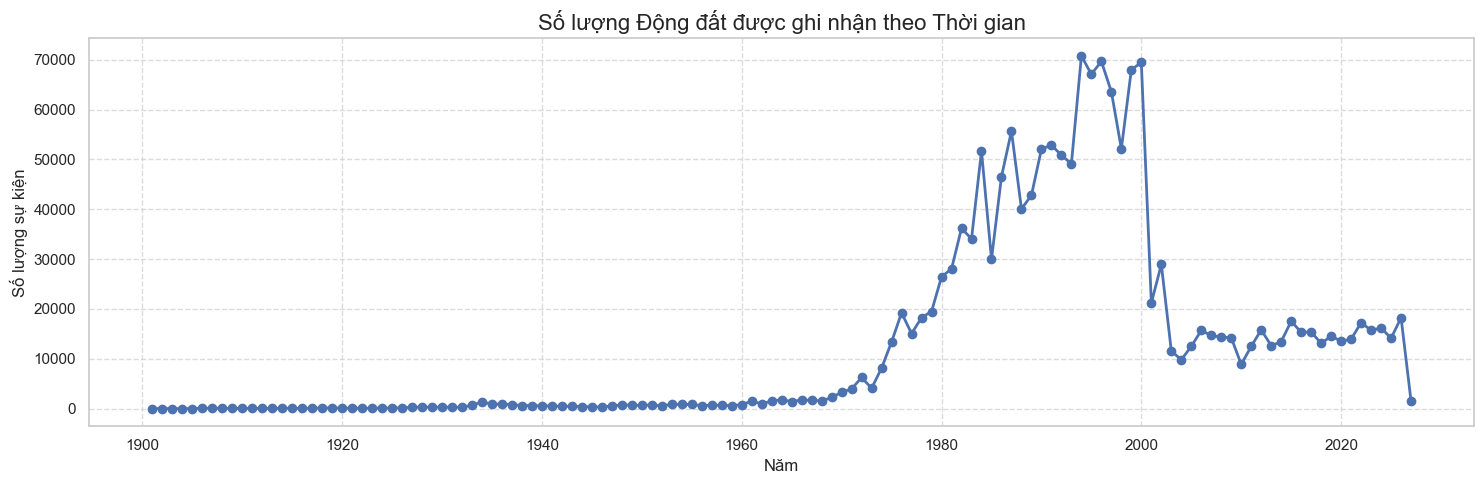

In [ ]:
df_time = df.dropna(subset=['Time']).copy()
df_time.set_index('Time', inplace=True)

plt.figure(figsize=(15, 5))

earthquakes_per_year = df_time.resample('Y').size()

plt.plot(earthquakes_per_year.index, earthquakes_per_year.values, 
         marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Số lượng Động đất được ghi nhận theo Thời gian', fontsize=16)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Số lượng sự kiện', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

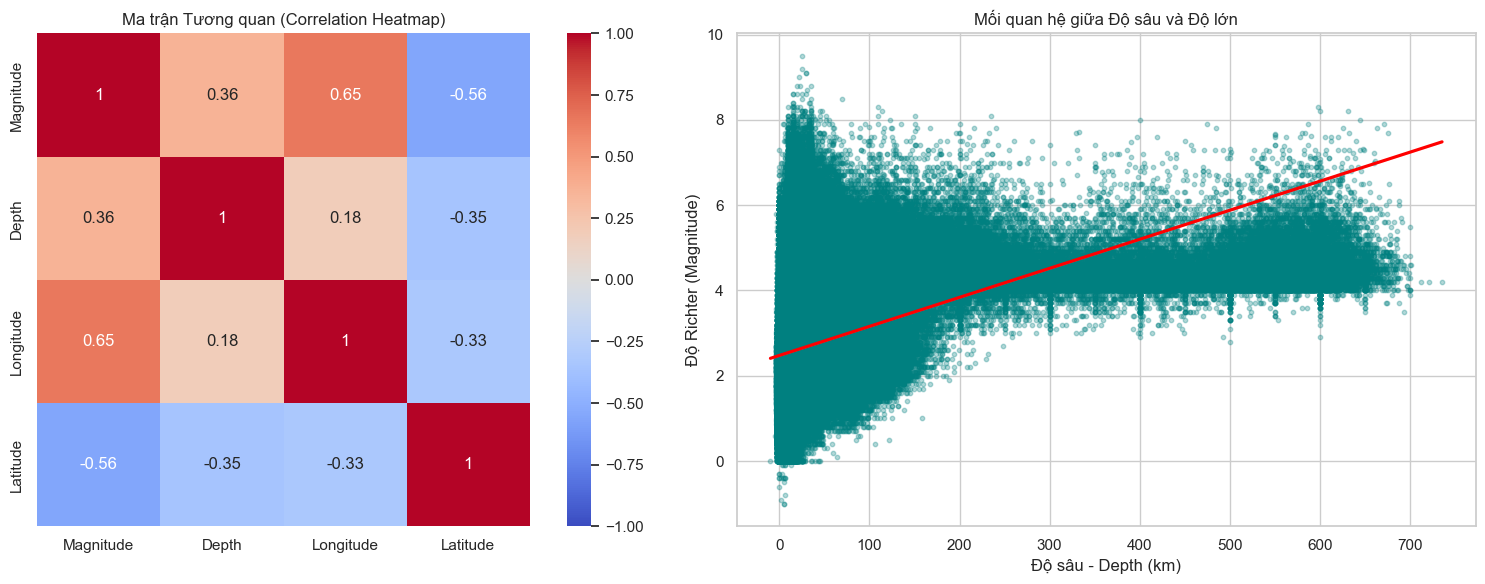

In [5]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
numerical_cols = ['Magnitude', 'Depth', 'Longitude', 'Latitude']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Ma trận Tương quan (Correlation Heatmap)')

plt.subplot(1, 2, 2)
sns.regplot(data=df, x='Depth', y='Magnitude', 
            scatter_kws={'alpha':0.3, 'color': 'teal', 's': 10}, 
            line_kws={'color': 'red'})
plt.title('Mối quan hệ giữa Độ sâu và Độ lớn')
plt.xlabel('Độ sâu - Depth (km)')
plt.ylabel('Độ Richter (Magnitude)')

plt.tight_layout()
plt.show()

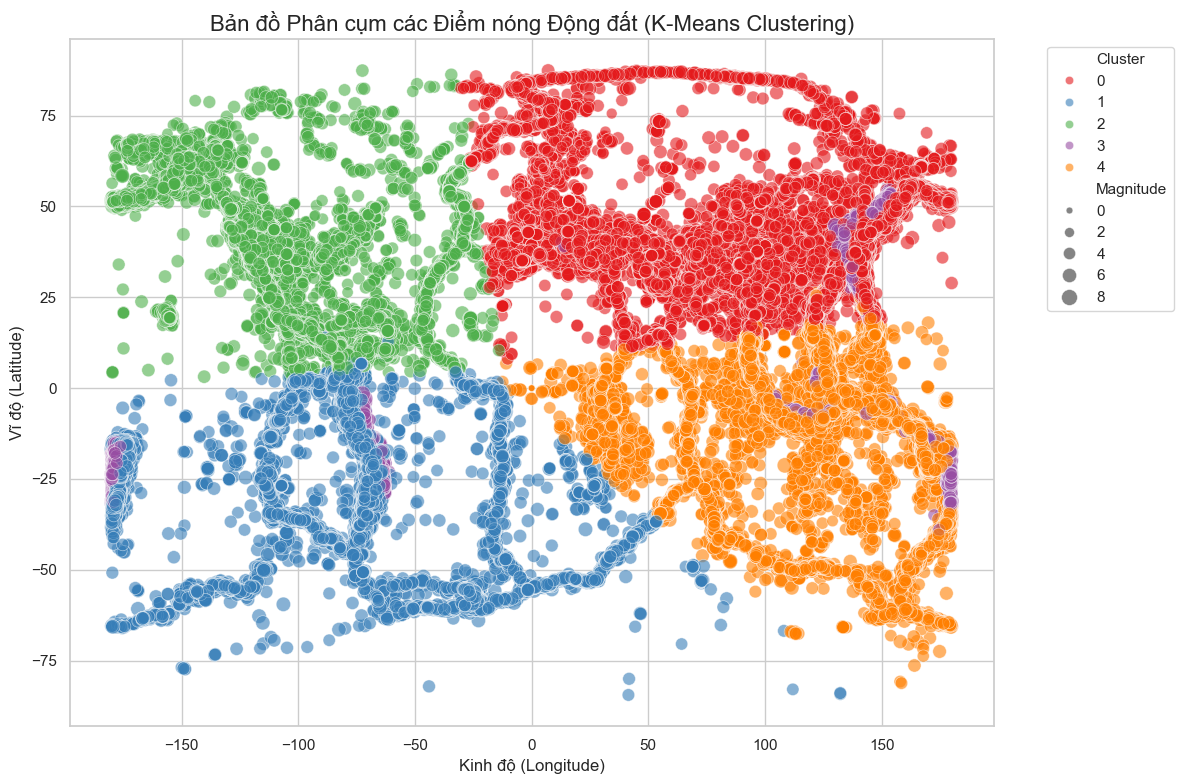

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_cluster = df.dropna(subset=['Longitude', 'Latitude', 'Depth']).copy()

X = df_cluster[['Longitude', 'Latitude', 'Depth']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_cluster, 
    x='Longitude', 
    y='Latitude', 
    hue='Cluster',       # Tô màu theo Cụm mà AI vừa gán
    palette='Set1',      # Bộ màu
    size='Magnitude',    # Vẫn giữ kích thước theo Magnitude
    sizes=(10, 150),
    alpha=0.6
)

plt.title('Bản đồ Phân cụm các Điểm nóng Động đất (K-Means Clustering)', fontsize=16)
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
import plotly.express as px

# Loại bỏ các dòng thiếu tọa độ hoặc Magnitude
df_map = df.dropna(subset=['Longitude', 'Latitude', 'Magnitude']).copy()

# XỬ LÝ LỖI: Tạo cột kích thước riêng. Nếu Magnitude <= 0 thì gán bằng 0.1
df_map['Marker_Size'] = df_map['Magnitude'].apply(lambda x: x if x > 0 else 0.1)

fig = px.scatter_geo(
    df_map,
    lon='Longitude',
    lat='Latitude',
    color='Magnitude',          # Màu sắc vẫn tính theo Magnitude gốc (có cả số âm)
    size='Marker_Size',         # KÍCH THƯỚC dùng cột mới đã vá lỗi
    color_continuous_scale='Reds', 
    hover_name='Place',         
    # Ẩn cột Marker_Size đi khi di chuột vào, chỉ hiện Magnitude gốc
    hover_data={'Time': True, 'Depth': True, 'Longitude': False, 'Latitude': False, 'Marker_Size': False, 'Magnitude': True}, 
    projection="natural earth", 
    title='Bản đồ Phân bố Động đất Toàn cầu',
    opacity=0.6                 
)

# Cập nhật giao diện bản đồ
fig.update_geos(
    showcountries=True, countrycolor="RebeccaPurple",
    showcoastlines=True, coastlinecolor="Black",
    showland=True, landcolor="LightGreen",
    showocean=True, oceancolor="LightBlue"
)

file_path = "ban_do_dong_dat.html"
fig.write_html(file_path)

print(f"Đã lưu bản đồ thành công tại file: {file_path}")

Đã lưu bản đồ thành công tại file: ban_do_dong_dat.html


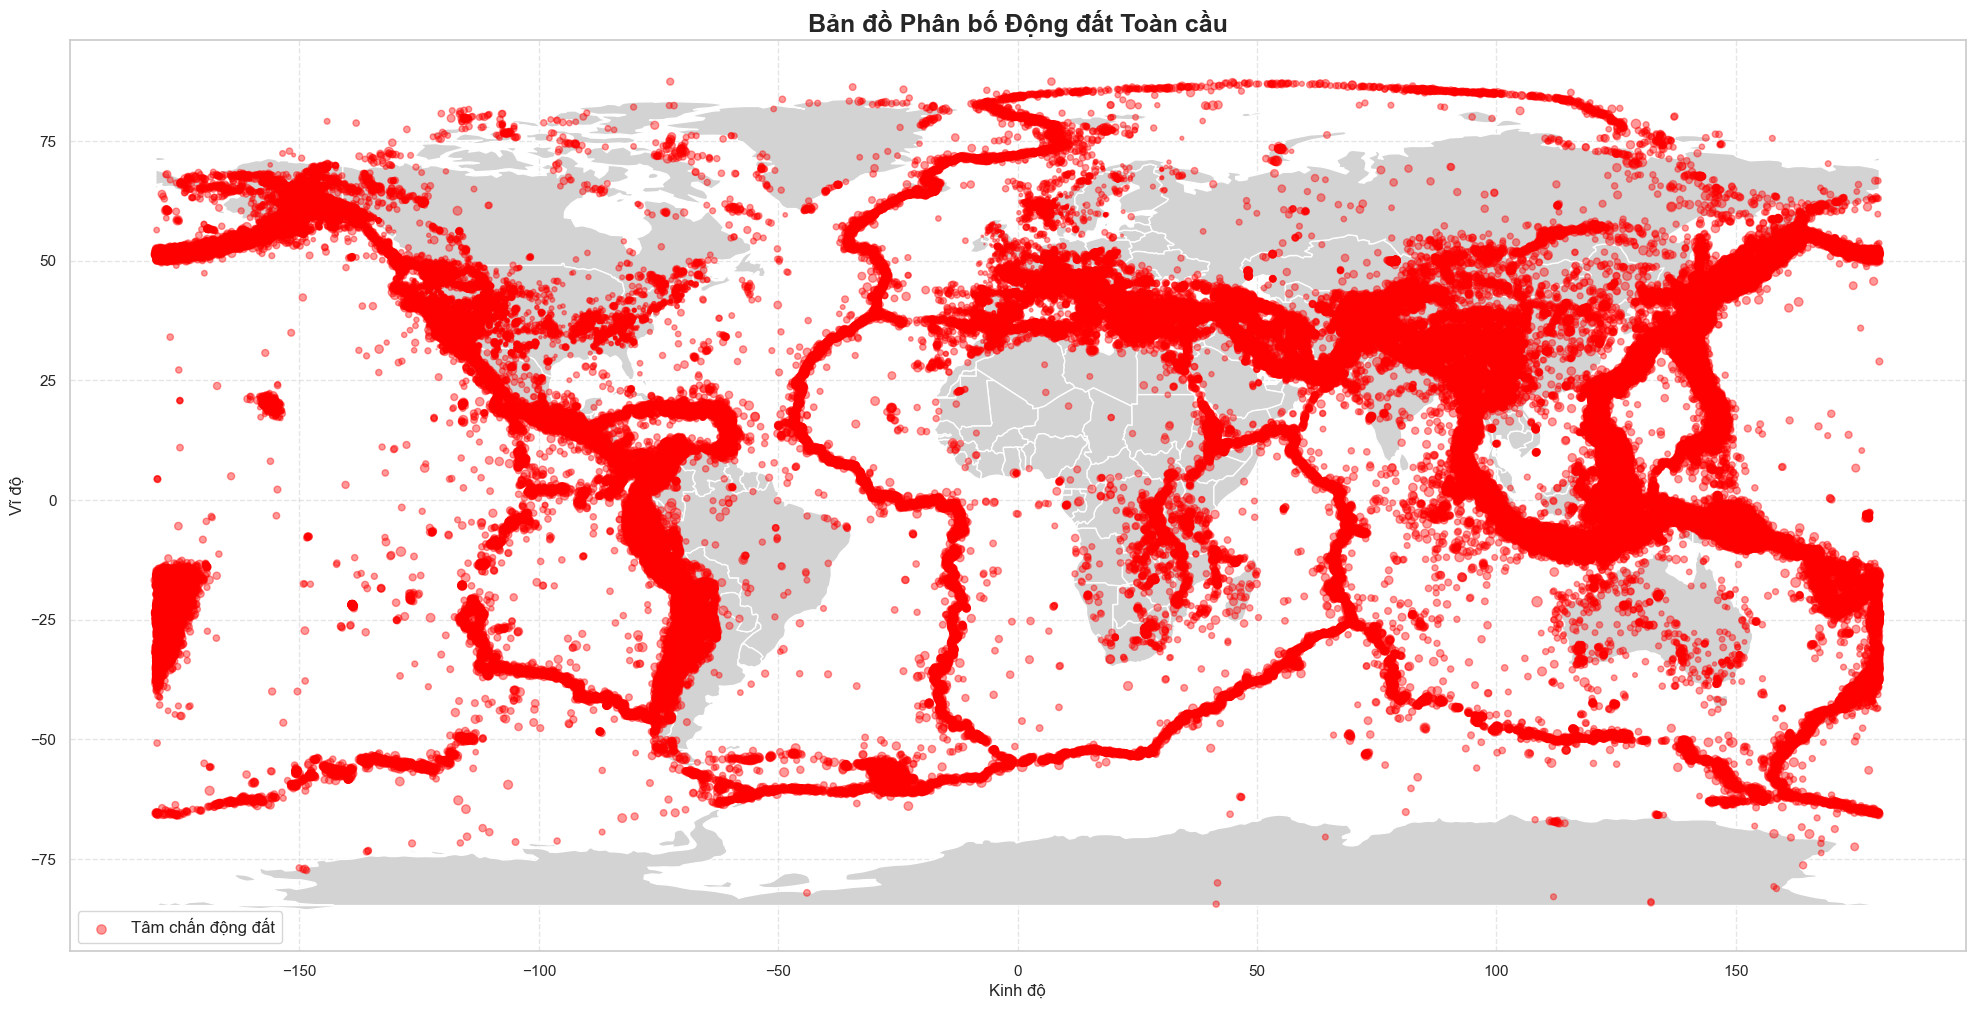

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

# --- ĐÃ SỬA LỖI TẠI ĐÂY ---
# Đọc file GeoJSON bản đồ thế giới trực tiếp từ Github thay vì dùng data tích hợp cũ
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)

# Chuyển đổi DataFrame bình thường của bạn thành GeoDataFrame
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude'])
)

# Tiến hành vẽ
fig, ax = plt.subplots(figsize=(20, 10))

# Vẽ nền bản đồ thế giới (các lục địa màu xám nhạt)
world.plot(ax=ax, color='lightgrey', edgecolor='white')

# Vẽ các điểm động đất lên trên
gdf.plot(
    ax=ax, 
    marker='o', 
    color='red', 
    markersize=df['Magnitude']**2, # Bình phương để tạo sự khác biệt
    alpha=0.4,                     
    label='Tâm chấn động đất'
)

plt.title('Bản đồ Phân bố Động đất Toàn cầu', fontsize=18, fontweight='bold')
plt.xlabel('Kinh độ', fontsize=12)
plt.ylabel('Vĩ độ', fontsize=12)
plt.legend(loc='lower left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()